# Part 2A-xi: Custom Training Loop — Fashion MNIST

**Objective:** Write a fully custom training loop in both TensorFlow (GradientTape) and PyTorch.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt, time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train.astype("float32").reshape(-1, 784) / 255.0
X_test = X_test.astype("float32").reshape(-1, 784) / 255.0
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
print(f"Fashion MNIST — Train: {X_train.shape}, Test: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Fashion MNIST — Train: (60000, 784), Test: (10000, 784)


## TensorFlow: Custom Training Loop with tf.GradientTape
Instead of `model.fit()`, we manually control the training loop.

In [2]:
# Build model
tf_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(300, activation='relu'),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='softmax')
])

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = keras.losses.SparseCategoricalCrossentropy()
train_loss_metric = keras.metrics.Mean(name='train_loss')
train_acc_metric = keras.metrics.SparseCategoricalAccuracy(name='train_acc')
val_loss_metric = keras.metrics.Mean(name='val_loss')
val_acc_metric = keras.metrics.SparseCategoricalAccuracy(name='val_acc')

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(10000).batch(256)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(256)

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        predictions = tf_model(x, training=True)
        loss = loss_fn(y, predictions)
    gradients = tape.gradient(loss, tf_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, tf_model.trainable_variables))
    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(y, predictions)

@tf.function
def val_step(x, y):
    predictions = tf_model(x, training=False)
    loss = loss_fn(y, predictions)
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y, predictions)

# Custom training loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
EPOCHS = 5

for epoch in range(EPOCHS):
    t0 = time.time()
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    for x_batch, y_batch in train_ds:
        train_step(x_batch, y_batch)

    val_loss_metric.reset_state()
    val_acc_metric.reset_state()
    for x_batch, y_batch in test_ds:
        val_step(x_batch, y_batch)

    tl, ta = float(train_loss_metric.result()), float(train_acc_metric.result())
    vl, va = float(val_loss_metric.result()), float(val_acc_metric.result())
    history['train_loss'].append(tl); history['train_acc'].append(ta)
    history['val_loss'].append(vl); history['val_acc'].append(va)

    print(f"Epoch {epoch+1:2d}/{EPOCHS} — {time.time()-t0:.1f}s — "
          f"train_loss: {tl:.4f}, train_acc: {ta:.4f}, val_loss: {vl:.4f}, val_acc: {va:.4f}")

Epoch  1/5 — 5.4s — train_loss: 0.5491, train_acc: 0.8092, val_loss: 0.4464, val_acc: 0.8420
Epoch  2/5 — 0.8s — train_loss: 0.3838, train_acc: 0.8616, val_loss: 0.4042, val_acc: 0.8532
Epoch  3/5 — 0.8s — train_loss: 0.3428, train_acc: 0.8761, val_loss: 0.3700, val_acc: 0.8689
Epoch  4/5 — 0.9s — train_loss: 0.3174, train_acc: 0.8843, val_loss: 0.3663, val_acc: 0.8695
Epoch  5/5 — 1.4s — train_loss: 0.2961, train_acc: 0.8921, val_loss: 0.3413, val_acc: 0.8766


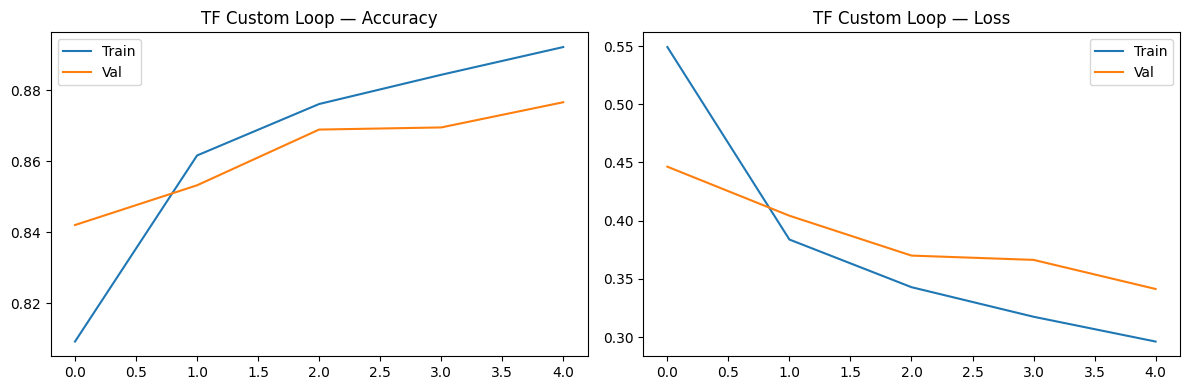

In [3]:
# Plot TF results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_acc'], label='Train'); axes[0].plot(history['val_acc'], label='Val')
axes[0].set_title('TF Custom Loop — Accuracy'); axes[0].legend()
axes[1].plot(history['train_loss'], label='Train'); axes[1].plot(history['val_loss'], label='Val')
axes[1].set_title('TF Custom Loop — Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

## PyTorch: Custom Training Loop

/tmp/ipykernel_11612/4293936470.py:15: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.utils.data.TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),


Epoch  1/5 — train_acc: 0.7836, val_acc: 0.8321
Epoch  2/5 — train_acc: 0.8535, val_acc: 0.8530
Epoch  3/5 — train_acc: 0.8679, val_acc: 0.8651
Epoch  4/5 — train_acc: 0.8776, val_acc: 0.8616
Epoch  5/5 — train_acc: 0.8858, val_acc: 0.8719


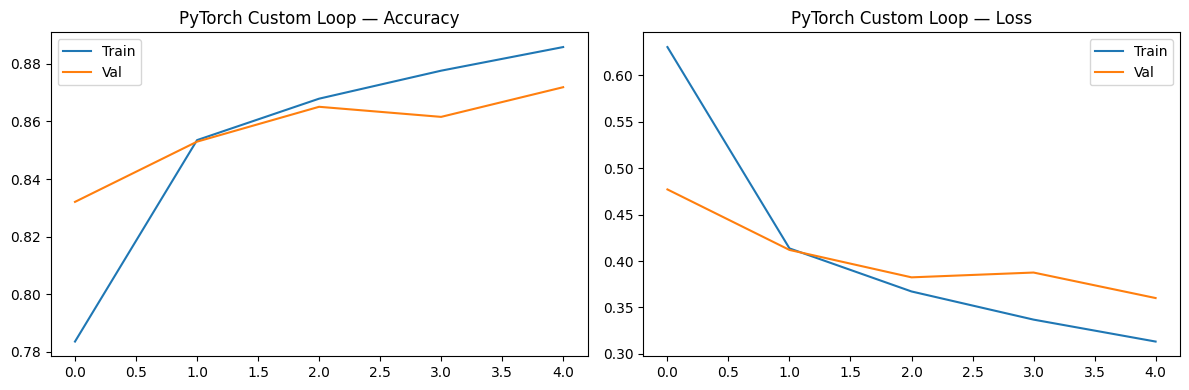

In [4]:
# PyTorch custom training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(784, 300), nn.ReLU(), nn.Linear(300, 100), nn.ReLU(), nn.Linear(100, 10))
    def forward(self, x): return self.net(x)

pt_model = FashionNet().to(device)
optimizer = torch.optim.Adam(pt_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)),
    batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)),
    batch_size=256)

pt_hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(5):
    pt_model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = pt_model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (outputs.argmax(1) == yb).sum().item()
        total += yb.size(0)

    pt_hist['train_loss'].append(running_loss / total)
    pt_hist['train_acc'].append(correct / total)

    pt_model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = pt_model(xb)
            val_loss += criterion(outputs, yb).item() * xb.size(0)
            correct += (outputs.argmax(1) == yb).sum().item()
            total += yb.size(0)

    pt_hist['val_loss'].append(val_loss / total)
    pt_hist['val_acc'].append(correct / total)
    print(f"Epoch {epoch+1:2d}/5 — train_acc: {pt_hist['train_acc'][-1]:.4f}, val_acc: {pt_hist['val_acc'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pt_hist['train_acc'], label='Train'); axes[0].plot(pt_hist['val_acc'], label='Val')
axes[0].set_title('PyTorch Custom Loop — Accuracy'); axes[0].legend()
axes[1].plot(pt_hist['train_loss'], label='Train'); axes[1].plot(pt_hist['val_loss'], label='Val')
axes[1].set_title('PyTorch Custom Loop — Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

## Key Takeaways
- Custom training loops give you full control: gradient accumulation, mixed precision, multi-GPU
- TF: `tf.GradientTape` records operations → compute gradients → apply with optimizer
- PyTorch: `loss.backward()` computes gradients → `optimizer.step()` updates weights
- `@tf.function` decorator compiles to graph mode for 2-3x speedup
- Always use `model.train()` / `model.eval()` in PyTorch (affects dropout, batchnorm)
- Essential for advanced scenarios: GANs, reinforcement learning, meta-learning